# Notebook 2 / 3 — Model Training
Loads the pre-generated data, fine-tunes Faster R-CNN, monitors validation each epoch, keeps the
best model. **Improvements vs first version:** random horizontal-flip augmentation (train only) and a
StepLR learning-rate scheduler — both reduce overfitting. The test set is never used here.


In [1]:
# Cell 1 — Setup
!pip install -q pycocotools opencv-python-headless

In [2]:
# Cell 2 — Config
import os, json, time, torch
import numpy as np, matplotlib.pyplot as plt
GLOBAL_SEED = 2025; torch.manual_seed(GLOBAL_SEED); np.random.seed(GLOBAL_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cpu": print("WARNING: GPU is OFF. Runtime > Change runtime type > T4 GPU.")
DATA_DIR = "synthetic_data"
CONFIG = {"MIN_SIZE": 512, "BATCH": 4, "EPOCHS": 8, "LR": 0.005, "AUGMENT": True}

In [3]:
# Cell 3 — Get data from Notebook 1 (mount Drive + unzip if needed)
from google.colab import drive; drive.mount('/content/drive')
import shutil; shutil.copy('/content/drive/MyDrive/synthetic_data.zip','synthetic_data.zip')
!unzip -q -o synthetic_data.zip -d synthetic_data
assert os.path.exists(os.path.join(DATA_DIR, "train_labels.json")), "Unzip dataset from Notebook 1 first."
print("Data found:", os.listdir(DATA_DIR))

Mounted at /content/drive
Data found: ['test_labels.json', 'test', 'figures', 'train', 'val', 'train_labels.json', 'val_labels.json']


In [4]:
# Cell 4 — # Reads pre-generated images + labels.json. Optional horizontal-flip augmentation (train only).
import os, json, torch
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset
from PIL import Image

class FileShapeDataset(Dataset):
    def __init__(self, data_dir, split, augment=False):
        self.img_dir = os.path.join(data_dir, split)
        with open(os.path.join(data_dir, f"{split}_labels.json")) as f:
            self.labels = json.load(f)
        self.files = sorted(self.labels.keys())
        self.augment = augment
    def __len__(self):
        return len(self.files)
    def __getitem__(self, i):
        fn = self.files[i]; rec = self.labels[fn]
        img = Image.open(os.path.join(self.img_dir, fn)).convert("RGB")
        img_t = TF.to_tensor(img)
        boxes = rec["boxes"]
        boxes_t = torch.as_tensor(boxes, dtype=torch.float32).reshape(-1, 4) if boxes \
                  else torch.zeros((0, 4), dtype=torch.float32)
        labels_t = torch.ones((len(boxes),), dtype=torch.int64) if boxes \
                   else torch.zeros((0,), dtype=torch.int64)
        if self.augment and torch.rand(1).item() < 0.5:           # random horizontal flip
            img_t = torch.flip(img_t, dims=[2]); W = img_t.shape[2]
            if len(boxes_t):
                x1 = boxes_t[:, 0].clone(); x2 = boxes_t[:, 2].clone()
                boxes_t[:, 0] = W - x2; boxes_t[:, 2] = W - x1
        target = {"boxes": boxes_t, "labels": labels_t,
                  "image_id": torch.tensor([rec["image_id"]]),
                  "is_positive": torch.tensor(rec["is_positive"])}
        return img_t, target

def collate_fn(b):
    return tuple(zip(*b))

In [5]:
# Cell 5 — # Faster R-CNN, fine-tuned. Backbone+FPN+RPN are COCO-pretrained; box head is new.
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def build_model(num_classes=2, min_size=512, weights="DEFAULT"):   # 0=background, 1=synthetic shape
    m = torchvision.models.detection.fasterrcnn_resnet50_fpn(
        weights=weights, min_size=min_size, max_size=min_size*2)
    in_feat = m.roi_heads.box_predictor.cls_score.in_features
    m.roi_heads.box_predictor = FastRCNNPredictor(in_feat, num_classes)
    return m

In [6]:
# Cell 6 — Datasets, loaders, model
from torch.utils.data import DataLoader
train_ds = FileShapeDataset(DATA_DIR, "train", augment=CONFIG["AUGMENT"])   # augmentation ON for train
val_ds   = FileShapeDataset(DATA_DIR, "val",   augment=False)
train_loader = DataLoader(train_ds, batch_size=CONFIG["BATCH"], shuffle=True,  collate_fn=collate_fn, num_workers=4)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG["BATCH"], shuffle=False, collate_fn=collate_fn, num_workers=4)
model = build_model(min_size=CONFIG["MIN_SIZE"]).to(DEVICE)
print("Datasets:", len(train_ds), len(val_ds))

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 226MB/s]


Datasets: 5000 1000


In [7]:
# Cell 7 — Report all training details (Section 7)
gpu = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
print("="*56)
print(" TRAINING CONFIGURATION")
print("="*56)
print(f" Input image size (min side) : {CONFIG['MIN_SIZE']} px")
print(f" Batch size                  : {CONFIG['BATCH']}")
print(f" Number of epochs            : {CONFIG['EPOCHS']}")
print(f" Optimizer                   : SGD (momentum=0.9, weight_decay=5e-4)")
print(f" LR / scheduler              : {CONFIG['LR']} / StepLR(step=3, gamma=0.5)")
print(f" Data augmentation           : horizontal flip = {CONFIG['AUGMENT']}")
print(f" Loss function               : Faster R-CNN multi-task (cls+box_reg+objectness+rpn_box_reg)")
print(f" Pretrained weights          : YES (COCO backbone+FPN+RPN); box head from scratch")
print(f" Hardware                    : {DEVICE} ({gpu})")
print(f" Train / Val images          : {len(train_ds)} / {len(val_ds)}")
print("="*56)

 TRAINING CONFIGURATION
 Input image size (min side) : 512 px
 Batch size                  : 4
 Number of epochs            : 8
 Optimizer                   : SGD (momentum=0.9, weight_decay=5e-4)
 LR / scheduler              : 0.005 / StepLR(step=3, gamma=0.5)
 Data augmentation           : horizontal flip = True
 Loss function               : Faster R-CNN multi-task (cls+box_reg+objectness+rpn_box_reg)
 Pretrained weights          : YES (COCO backbone+FPN+RPN); box head from scratch
 Hardware                    : cuda (NVIDIA RTX PRO 6000 Blackwell Server Edition)
 Train / Val images          : 5000 / 1000


In [8]:
# Cell 8 — Train: live progress + per-epoch val loss + StepLR + best-model checkpoint
def to_dev(targets):
    return [{k: v.to(DEVICE) for k, v in t.items() if k in ("boxes", "labels")} for t in targets]

@torch.no_grad()
def val_loss(model, loader):
    model.train(); tot, nb = 0.0, 0
    for imgs, targets in loader:
        imgs = [i.to(DEVICE) for i in imgs]
        tot += sum(model(imgs, to_dev(targets)).values()).item(); nb += 1
    return tot / max(nb, 1)

optimizer = torch.optim.SGD([p for p in model.parameters() if p.requires_grad],
                            lr=CONFIG["LR"], momentum=0.9, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

hist = {"train": [], "val": []}; n_batches = len(train_loader); best_val = float("inf")
t_start = time.time()
for ep in range(CONFIG["EPOCHS"]):
    model.train(); run, t0 = 0.0, time.time()
    for bi, (imgs, targets) in enumerate(train_loader):
        imgs = [i.to(DEVICE) for i in imgs]
        loss = sum(model(imgs, to_dev(targets)).values())
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        run += loss.item()
        if bi % 20 == 0:
            el = time.time() - t0; eta = el/(bi+1)*(n_batches-bi-1)
            print(f"  ep{ep+1} {bi}/{n_batches} | loss {loss.item():.3f} | elapsed {el:.0f}s | eta {eta:.0f}s", flush=True)
    scheduler.step()
    tr = run/n_batches; vl = val_loss(model, val_loader)
    hist["train"].append(tr); hist["val"].append(vl)
    flag = ""
    if vl < best_val:
        best_val = vl; torch.save(model.state_dict(), "best_model.pth"); flag = "  << best saved"
    print(f"Epoch {ep+1}/{CONFIG['EPOCHS']} | train {tr:.3f} | val {vl:.3f} | lr {optimizer.param_groups[0]['lr']:.4f} | {time.time()-t0:.0f}s{flag}")
torch.save(model.state_dict(), "last_model.pth")
print(f"Approximate training time: {(time.time()-t_start)/60:.1f} min on {DEVICE}")

  ep1 0/1250 | loss 1.096 | elapsed 2s | eta 2409s
  ep1 20/1250 | loss 0.498 | elapsed 4s | eta 212s
  ep1 40/1250 | loss 0.261 | elapsed 5s | eta 150s
  ep1 60/1250 | loss 0.581 | elapsed 7s | eta 127s
  ep1 80/1250 | loss 0.228 | elapsed 8s | eta 115s
  ep1 100/1250 | loss 0.235 | elapsed 9s | eta 105s
  ep1 120/1250 | loss 0.353 | elapsed 11s | eta 98s
  ep1 140/1250 | loss 0.119 | elapsed 12s | eta 93s
  ep1 160/1250 | loss 0.261 | elapsed 13s | eta 89s
  ep1 180/1250 | loss 0.248 | elapsed 14s | eta 86s
  ep1 200/1250 | loss 0.232 | elapsed 16s | eta 83s
  ep1 220/1250 | loss 0.239 | elapsed 17s | eta 80s
  ep1 240/1250 | loss 0.104 | elapsed 18s | eta 77s
  ep1 260/1250 | loss 0.146 | elapsed 20s | eta 75s
  ep1 280/1250 | loss 0.134 | elapsed 21s | eta 73s
  ep1 300/1250 | loss 0.244 | elapsed 22s | eta 71s
  ep1 320/1250 | loss 0.157 | elapsed 24s | eta 68s
  ep1 340/1250 | loss 0.100 | elapsed 25s | eta 66s
  ep1 360/1250 | loss 0.269 | elapsed 26s | eta 65s
  ep1 380/1250 | 

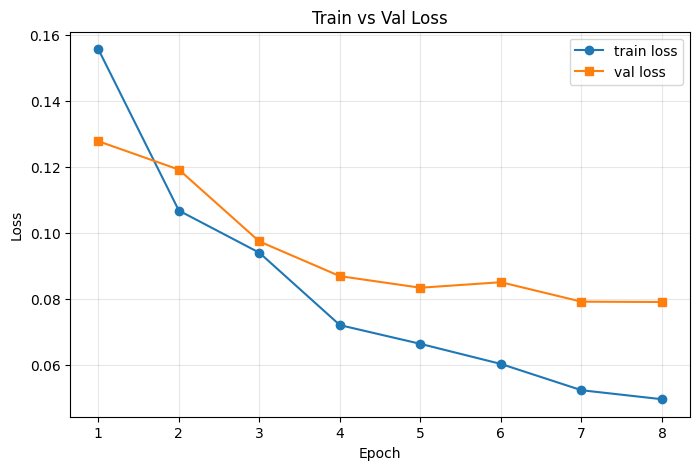

Saved best_model.pth, last_model.pth, loss_curve.png


In [9]:
# Cell 9 — Loss curve (overfitting check)
ep = range(1, len(hist["train"]) + 1)
plt.figure(figsize=(8, 5))
plt.plot(ep, hist["train"], "o-", label="train loss"); plt.plot(ep, hist["val"], "s-", label="val loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Train vs Val Loss"); plt.legend(); plt.grid(alpha=.3)
os.makedirs("results/figures", exist_ok=True)
plt.savefig("results/figures/loss_curve.png", dpi=120, bbox_inches="tight"); plt.show()
with open("results/train_history.json", "w") as f: json.dump(hist, f, indent=2)
print("Saved best_model.pth, last_model.pth, loss_curve.png")

In [10]:
# Cell 10 — Upload model to Drive
from google.colab import drive; drive.mount('/content/drive')
import shutil; shutil.copy('best_model.pth', '/content/drive/MyDrive/best_model.pth')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/drive/MyDrive/best_model.pth'